In [10]:
pip install yfinance

In [15]:
import yfinance as yf
import pandas as pd
print(pd.__version__)

print("librerias cargadas correctamente")

2.2.2
librerias cargadas correctamente


In [18]:
GOOGL = yf.Ticker("GOOGL")
GOOGL.info

{'address1': '1600 Amphitheatre Parkway',
 'city': 'Mountain View',
 'state': 'CA',
 'zip': '94043',
 'country': 'United States',
 'phone': '650-253-0000',
 'website': 'https://abc.xyz',
 'industry': 'Internet Content & Information',
 'industryKey': 'internet-content-information',
 'industryDisp': 'Internet Content & Information',
 'sector': 'Communication Services',
 'sectorKey': 'communication-services',
 'sectorDisp': 'Communication Services',
 'longBusinessSummary': 'Alphabet Inc. offers various products and platforms in the United States, Europe, the Middle East, Africa, the Asia-Pacific, Canada, and Latin America. It operates through Google Services, Google Cloud, and Other Bets segments. The Google Services segment provides products and services, including ads, Android, Chrome, devices, Gmail, Google Drive, Google Maps, Google Photos, Google Play, Search, and YouTube. It is also involved in the sale of apps and in-app purchases and digital content in the Google Play and YouTube;

/tmp/ipython-input-180133073.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google = yf.download("GOOGL", period="5y")
[*********************100%***********************]  1 of 1 completed

Pendiente: [0.06963261]


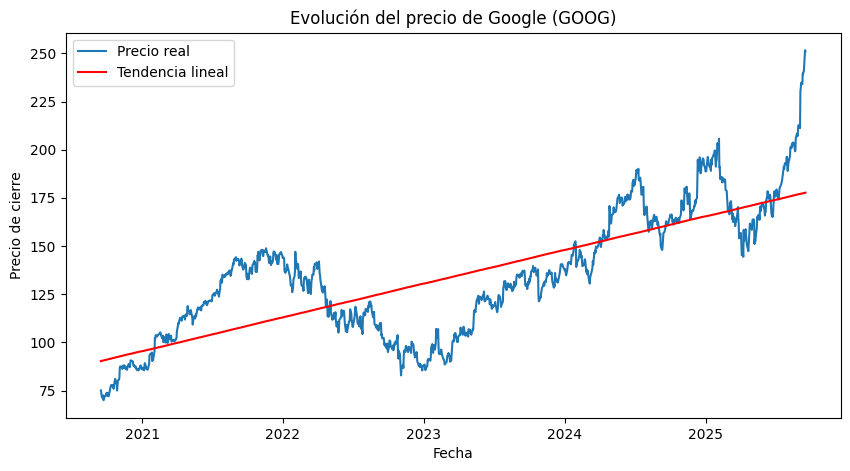

In [17]:
google = yf.download("GOOGL", period="5y")

from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

google['Days'] = np.arange(len(google))
X = google[['Days']]
y = google['Close']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]  # pendiente
print("Pendiente:", slope)

plt.figure(figsize=(10,5))
plt.plot(google.index, google['Close'], label="Precio real")
plt.plot(google.index, model.predict(X), color='red', label="Tendencia lineal")
plt.title("Evolución del precio de Google (GOOG)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.show()

In [ ]:

if slope > 0:
    print("El precio de Google muestra una tendencia creciente.")
else:
    print("El precio de Google no muestra una tendencia creciente.")

El precio de Google muestra una tendencia creciente.


/tmp/ipython-input-3061427500.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google = yf.download("GOOG", period="5y")
[*********************100%***********************]  1 of 1 completed

Promedio móvil inicial: 75.12923634847006
Promedio móvil final: 215.99971618652344
✅ El precio de Google muestra tendencia creciente.


<Axes: title={'center': 'Precio de Google (GOOG) con promedio móvil de 30 días'}, xlabel='Date'>

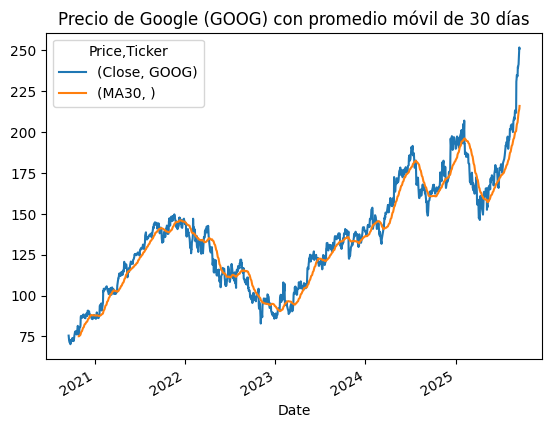

In [14]:
import yfinance as yf
import pandas as pd

# 1. Descargar precios de Google (últimos 5 años)
google = yf.download("GOOG", period="5y")

# 2. Calcular promedio móvil de 30 días
google['MA30'] = google['Close'].rolling(30).mean()

# 3. Comparar valores iniciales y finales
start = google['MA30'].iloc[30]   # primer valor válido del promedio móvil
end = google['MA30'].iloc[-1]     # último valor

print("Promedio móvil inicial:", start)
print("Promedio móvil final:", end)

if end > start:
    print("✅ El precio de Google muestra tendencia creciente.")
else:
    print("❌ El precio de Google no muestra tendencia creciente.")

# 4. Graficar precios y promedio móvil
google[['Close', 'MA30']].plot(title="Precio de Google (GOOG) con promedio móvil de 30 días")
